# 데이터셋 토큰 길이 분포 분석

`jjun123/deliveryapp-traindata-100` 데이터셋의 토큰 길이 분포를 확인하여
적절한 `max_seq_length` 값을 결정합니다.

In [1]:
from datasets import load_dataset
from transformers import AutoTokenizer
import matplotlib.pyplot as plt
import numpy as np

/home/cwj/llm-project/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 설정
DATASET_ID = "jjun123/deliveryapp-traindata-100"
MODEL_ID = "Qwen/Qwen2.5-7B-Instruct"

# org_train.py에서 사용하는 데이터셋 (비교용)
ORG_DATASET_ID = "iamjoon/ecommerce-function-calling-datasets-korean"

In [3]:
# 토크나이저 로드
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

START_TOKEN = "<|im_start|>"
END_TOKEN = "<|im_end|>"

In [4]:
def build_chatml_prompt(sample):
    """샘플을 ChatML 형식 문자열로 변환합니다."""
    prompt = ""
    # system_prompt가 있으면 추가
    if "system_prompt" in sample and sample["system_prompt"]:
        prompt += f"{START_TOKEN}system\n{sample['system_prompt'].strip()}{END_TOKEN}"
    for msg in sample["messages"]:
        role = msg["role"]
        content = msg["content"].strip()
        prompt += f"{START_TOKEN}{role}\n{content}{END_TOKEN}"
    return prompt


def get_token_lengths(dataset, name=""):
    """데이터셋의 각 샘플별 토큰 길이를 계산합니다."""
    lengths = []
    for sample in dataset:
        prompt = build_chatml_prompt(sample)
        tokens = tokenizer.encode(prompt, add_special_tokens=False)
        lengths.append(len(tokens))
    print(f"[{name}] {len(lengths)}개 샘플 토큰 길이 계산 완료")
    return lengths

## 1. train/run.py 데이터셋 분석

In [5]:
ds_run = load_dataset(DATASET_ID, split="train")
print(f"데이터셋 크기: {len(ds_run)}개")
print(f"컬럼: {ds_run.column_names}")
print(f"\n첫 번째 샘플 키: {list(ds_run[0].keys())}")

데이터셋 크기: 99개
컬럼: ['tools', 'uid', 'dates', 'messages', 'system_prompt']

첫 번째 샘플 키: ['tools', 'uid', 'dates', 'messages', 'system_prompt']


In [6]:
ds_run[0]

{'tools': [{'description': '식당 목록을 검색/필터/정렬하여 페이지 단위로 반환합니다. 식당명이나 메뉴명으로 검색하거나, 카테고리·최소 평점·영업 여부로 필터링할 수 있습니다.',
   'name': 'search_restaurants',
   'parameters': {'additionalProperties': False,
    'properties': {'address_id': None,
     'at': None,
     'cart_item_id': None,
     'cart_item_ids': None,
     'category': {'description': "음식 카테고리 필터 (예: '한식', '중식', '피자')",
      'type': 'string'},
     'delivery_note': None,
     'gate_password': None,
     'is_default': None,
     'line1': None,
     'line2': None,
     'menu_item_id': None,
     'min_rating': {'description': '최소 평점 필터 (0.0 ~ 5.0)', 'type': 'number'},
     'only_open': {'default': False,
      'description': 'true이면 현재 영업 중인 식당만 반환',
      'type': 'boolean'},
     'order_id': None,
     'page': {'default': 1,
      'description': '페이지 번호 (1부터 시작)',
      'type': 'integer'},
     'page_size': {'default': 20,
      'description': '페이지당 항목 수',
      'type': 'integer'},
     'payment_method': None,
     'pg_id': None,
    

In [7]:
lengths_run = get_token_lengths(ds_run, name=DATASET_ID)

[jjun123/deliveryapp-traindata-100] 99개 샘플 토큰 길이 계산 완료


## 2. org_train.py 데이터셋 분석 (비교용)

In [8]:
ds_org = load_dataset(ORG_DATASET_ID, split="train")
print(f"데이터셋 크기: {len(ds_org)}개")
print(f"컬럼: {ds_org.column_names}")

lengths_org = get_token_lengths(ds_org, name=ORG_DATASET_ID)

데이터셋 크기: 388개
컬럼: ['tools', 'cid', 'dates', 'messages', 'system_prompt']
[iamjoon/ecommerce-function-calling-datasets-korean] 388개 샘플 토큰 길이 계산 완료


## 3. 통계 비교

In [9]:
def print_stats(lengths, name):
    arr = np.array(lengths)
    print(f"=== {name} ===")
    print(f"  샘플 수   : {len(arr)}")
    print(f"  최소      : {arr.min():,} tokens")
    print(f"  최대      : {arr.max():,} tokens")
    print(f"  평균      : {arr.mean():,.1f} tokens")
    print(f"  중앙값    : {np.median(arr):,.1f} tokens")
    print(f"  표준편차  : {arr.std():,.1f} tokens")
    print(f"  P90       : {np.percentile(arr, 90):,.0f} tokens")
    print(f"  P95       : {np.percentile(arr, 95):,.0f} tokens")
    print(f"  P99       : {np.percentile(arr, 99):,.0f} tokens")
    print()
    
    # max_seq_length별 잘리는 비율
    for limit in [2048, 4096, 6144, 8192]:
        over = (arr > limit).sum()
        pct = over / len(arr) * 100
        print(f"  > {limit:,} tokens: {over}개 ({pct:.1f}%)")
    print()

print_stats(lengths_run, DATASET_ID)
print_stats(lengths_org, ORG_DATASET_ID)

=== jjun123/deliveryapp-traindata-100 ===
  샘플 수   : 99
  최소      : 3,190 tokens
  최대      : 8,831 tokens
  평균      : 5,403.1 tokens
  중앙값    : 5,319.0 tokens
  표준편차  : 1,143.4 tokens
  P90       : 6,682 tokens
  P95       : 7,578 tokens
  P99       : 8,039 tokens

  > 2,048 tokens: 99개 (100.0%)
  > 4,096 tokens: 85개 (85.9%)
  > 6,144 tokens: 27개 (27.3%)
  > 8,192 tokens: 1개 (1.0%)

=== iamjoon/ecommerce-function-calling-datasets-korean ===
  샘플 수   : 388
  최소      : 1,968 tokens
  최대      : 2,924 tokens
  평균      : 2,348.6 tokens
  중앙값    : 2,331.5 tokens
  표준편차  : 176.8 tokens
  P90       : 2,574 tokens
  P95       : 2,632 tokens
  P99       : 2,844 tokens

  > 2,048 tokens: 378개 (97.4%)
  > 4,096 tokens: 0개 (0.0%)
  > 6,144 tokens: 0개 (0.0%)
  > 8,192 tokens: 0개 (0.0%)



## 4. 히스토그램 시각화

/tmp/ipykernel_2455274/3168488033.py:24: UserWarning: Glyph 45936 (\N{HANGUL SYLLABLE DE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2455274/3168488033.py:24: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2455274/3168488033.py:24: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2455274/3168488033.py:24: UserWarning: Glyph 49483 (\N{HANGUL SYLLABLE SES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2455274/3168488033.py:24: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2455274/3168488033.py:24: UserWarning: Glyph 53664 (\N{HANGUL SYLLABLE TO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2455274/3168488033.py:24: UserWarning: Glyph 53360 (\N{HANGUL SYLLABLE KEUN}) missing from font(s) DejaVu

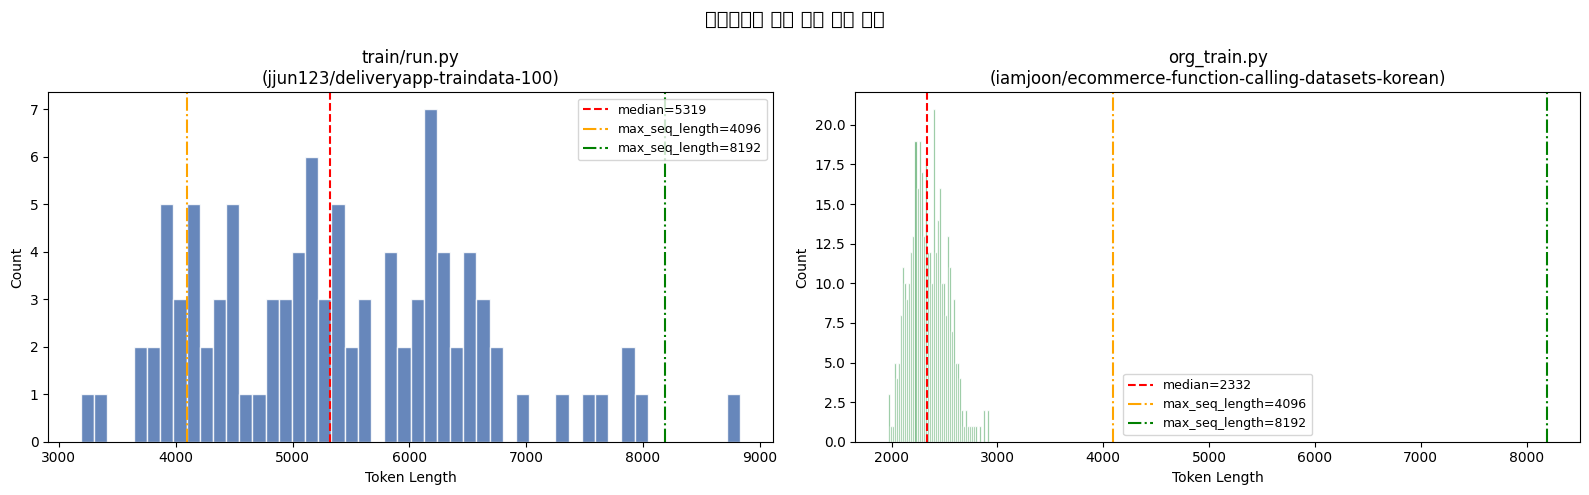

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# train/run.py 데이터셋
axes[0].hist(lengths_run, bins=50, color="#4C72B0", edgecolor="white", alpha=0.85)
axes[0].axvline(np.median(lengths_run), color="red", linestyle="--", label=f"median={np.median(lengths_run):.0f}")
axes[0].axvline(4096, color="orange", linestyle="-.", label="max_seq_length=4096")
axes[0].axvline(8192, color="green", linestyle="-.", label="max_seq_length=8192")
axes[0].set_title(f"train/run.py\n({DATASET_ID})", fontsize=12)
axes[0].set_xlabel("Token Length")
axes[0].set_ylabel("Count")
axes[0].legend(fontsize=9)

# org_train.py 데이터셋
axes[1].hist(lengths_org, bins=50, color="#55A868", edgecolor="white", alpha=0.85)
axes[1].axvline(np.median(lengths_org), color="red", linestyle="--", label=f"median={np.median(lengths_org):.0f}")
axes[1].axvline(4096, color="orange", linestyle="-.", label="max_seq_length=4096")
axes[1].axvline(8192, color="green", linestyle="-.", label="max_seq_length=8192")
axes[1].set_title(f"org_train.py\n({ORG_DATASET_ID})", fontsize=12)
axes[1].set_xlabel("Token Length")
axes[1].set_ylabel("Count")
axes[1].legend(fontsize=9)

plt.suptitle("데이터셋별 토큰 길이 분포 비교", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. 박스플롯 비교

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
bp = ax.boxplot(
    [lengths_run, lengths_org],
    labels=[f"run.py\n({DATASET_ID})", f"org_train.py\n({ORG_DATASET_ID})"],
    vert=False,
    patch_artist=True,
)
bp["boxes"][0].set_facecolor("#4C72B0")
bp["boxes"][1].set_facecolor("#55A868")

for limit, color in [(2048, "gray"), (4096, "orange"), (8192, "green")]:
    ax.axvline(limit, color=color, linestyle="--", alpha=0.6, label=f"{limit}")

ax.set_xlabel("Token Length")
ax.set_title("토큰 길이 박스플롯 비교", fontsize=13, fontweight="bold")
ax.legend(title="max_seq_length", fontsize=9)
plt.tight_layout()
plt.show()

## 6. VRAM 사용량 추정

시퀀스 길이에 따른 cross_entropy logits 텐서 크기를 추정합니다.  
이 텐서가 OOM의 직접적 원인입니다 (`shift_logits`: `[batch, seq_len, vocab_size]`).

In [ ]:
vocab_size = tokenizer.vocab_size
print(f"Vocab size: {vocab_size:,}")
print()

print("seq_len  | logits 텐서 크기 (bf16) | batch=1 | batch=2")
print("-" * 60)
for seq_len in [1024, 2048, 4096, 6144, 8192]:
    # bf16 = 2 bytes per element
    size_b1 = seq_len * vocab_size * 2  # bytes, batch=1
    size_b2 = size_b1 * 2
    print(f"{seq_len:>7,}  | {seq_len:,} × {vocab_size:,} × 2B    | {size_b1 / 1e9:.2f} GB  | {size_b2 / 1e9:.2f} GB")

## 7. 결론 & 권장 max_seq_length

In [ ]:
arr_run = np.array(lengths_run)
p95 = int(np.percentile(arr_run, 95))
p99 = int(np.percentile(arr_run, 99))

# 2의 거듭제곱으로 올림
import math
recommended = 2 ** math.ceil(math.log2(p95))

print(f"run.py 데이터셋 P95 토큰 길이: {p95:,}")
print(f"run.py 데이터셋 P99 토큰 길이: {p99:,}")
print(f"\n권장 max_seq_length: {recommended:,}")
print(f"  → P95 기준으로 2의 거듭제곱으로 올림")
print(f"  → 상위 5% 샘플은 truncation됨 (학습 품질에 미미한 영향)")